<a href="https://colab.research.google.com/github/sachini9-git/northstar-databases-analytics/blob/main/02_r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ============================================================
# Notebook 2: R Analytics
# Step 1: Install and Load R Packages
# ============================================================
# Purpose:
# Load R packages required for business analytics, data transformation,
# summary tables and visualisations.
# ============================================================

system("apt-get update -qq")
system("apt-get install -y -qq r-cran-dplyr r-cran-ggplot2 r-cran-readr r-cran-lubridate")

library(dplyr)
library(ggplot2)
library(readr)
library(lubridate)

print("R analytics packages loaded successfully: dplyr, ggplot2, readr, lubridate.")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




[1] "R analytics packages loaded successfully: dplyr, ggplot2, readr, lubridate."


In [6]:
# ============================================================
# Step 2: Import NorthStar Datasets from GitHub
# ============================================================
# Purpose:
# Load the NorthStar datasets directly from GitHub so the R analytics
# notebook is reproducible.
# ============================================================

base_url <- "https://raw.githubusercontent.com/sachini9-git/northstar-databases-analytics/main/data/raw"

customers <- read_csv(paste0(base_url, "/customers.csv"), show_col_types = FALSE)
orders <- read_csv(paste0(base_url, "/orders.csv"), show_col_types = FALSE)
deliveries <- read_csv(paste0(base_url, "/deliveries.csv"), show_col_types = FALSE)
drivers <- read_csv(paste0(base_url, "/drivers.csv"), show_col_types = FALSE)
vehicles <- read_csv(paste0(base_url, "/vehicles.csv"), show_col_types = FALSE)
hubs <- read_csv(paste0(base_url, "/hubs.csv"), show_col_types = FALSE)
incidents <- read_csv(paste0(base_url, "/incidents.csv"), show_col_types = FALSE)
complaints <- read_csv(paste0(base_url, "/complaints.csv"), show_col_types = FALSE)
app_events <- read_csv(paste0(base_url, "/app_events.csv"), show_col_types = FALSE)
data_dictionary <- read_csv(paste0(base_url, "/data_dictionary.csv"), show_col_types = FALSE)

dataset_summary <- data.frame(
  Dataset = c(
    "customers", "orders", "deliveries", "drivers", "vehicles",
    "hubs", "incidents", "complaints", "app_events", "data_dictionary"
  ),
  Records = c(
    nrow(customers), nrow(orders), nrow(deliveries), nrow(drivers), nrow(vehicles),
    nrow(hubs), nrow(incidents), nrow(complaints), nrow(app_events), nrow(data_dictionary)
  ),
  Columns = c(
    ncol(customers), ncol(orders), ncol(deliveries), ncol(drivers), ncol(vehicles),
    ncol(hubs), ncol(incidents), ncol(complaints), ncol(app_events), ncol(data_dictionary)
  )
)

print("NorthStar datasets imported successfully.")
print(dataset_summary)

[1] "NorthStar datasets imported successfully."
           Dataset Records Columns
1        customers     650       9
2           orders    1250      11
3       deliveries     950      13
4          drivers     170       8
5         vehicles     120       8
6             hubs       8       5
7        incidents     280       7
8       complaints     320      10
9       app_events     640      10
10 data_dictionary       9       3


In [7]:
# ============================================================
# Step 3: Create Clear Table Output Function
# ============================================================
# Purpose:
# Create clean report-style tables for screenshots and interpretation.
# ============================================================

if (!require(IRdisplay)) {
  install.packages("IRdisplay", repos = "https://cran.r-project.org")
  library(IRdisplay)
}

escape_html <- function(x) {
  x <- as.character(x)
  x <- gsub("&", "&amp;", x, fixed = TRUE)
  x <- gsub("<", "&lt;", x, fixed = TRUE)
  x <- gsub(">", "&gt;", x, fixed = TRUE)
  return(x)
}

nice_table <- function(df, title = "Output Table", max_rows = 20) {
  df <- as.data.frame(df)

  if (nrow(df) > max_rows) {
    df_display <- head(df, max_rows)
    note <- paste0(
      "<p style='font-size:13px;color:#333;'>Showing first ",
      max_rows, " rows from ", nrow(df), " rows.</p>"
    )
  } else {
    df_display <- df
    note <- ""
  }

  header_html <- paste0(
    "<tr>",
    paste0(
      "<th style='background-color:#1F4E79;color:white;border:1px solid #BFBFBF;padding:9px;text-align:left;font-weight:bold;'>",
      escape_html(names(df_display)),
      "</th>",
      collapse = ""
    ),
    "</tr>"
  )

  row_html <- apply(df_display, 1, function(row) {
    paste0(
      "<tr>",
      paste0(
        "<td style='color:black;border:1px solid #D9D9D9;padding:8px;background-color:white;text-align:left;'>",
        escape_html(row),
        "</td>",
        collapse = ""
      ),
      "</tr>"
    )
  })

  table_html <- paste0(
    "<div style='font-family:Arial;background-color:white;padding:12px;border-radius:8px;border:1px solid #BFBFBF;overflow-x:auto;'>",
    "<h3 style='color:#1F4E79;margin-bottom:8px;'>", title, "</h3>",
    note,
    "<table style='border-collapse:collapse;width:100%;font-size:14px;color:black;'>",
    "<thead>", header_html, "</thead>",
    "<tbody>", paste0(row_html, collapse = ""), "</tbody>",
    "</table>",
    "</div>"
  )

  IRdisplay::display_html(table_html)
}

print("Clear table function is ready.")

Loading required package: IRdisplay



[1] "Clear table function is ready."


In [8]:
# ============================================================
# Step 4: Dataset Overview for R Analytics
# ============================================================
# Purpose:
# Confirm the datasets available for R-based business analytics.
# ============================================================

nice_table(
  dataset_summary,
  title = "NorthStar Dataset Summary for R Analytics"
)

nice_table(
  data_dictionary,
  title = "NorthStar Data Dictionary"
)

Dataset,Records,Columns
customers,650,9
orders,1250,11
deliveries,950,13
drivers,170,8
vehicles,120,8
hubs,8,5
incidents,280,7
complaints,320,10
app_events,640,10
data_dictionary,9,3


file_name,record_count,description
hubs.csv,8,Operational hubs and control points
customers.csv,650,Customer master data with engagement and loyalty metrics
drivers.csv,170,Driver workforce data with training and rating information
vehicles.csv,120,Fleet asset data including battery and maintenance indicators
orders.csv,1250,Service orders across mobility and logistics operations
deliveries.csv,950,Operational dispatch and completion outcomes
incidents.csv,280,Delivery and asset incident records
complaints.csv,320,Customer complaints and compensation handling
app_events.csv,640,Digital platform events suitable for MongoDB reshaping


In [9]:
# ============================================================
# Step 5: Data Quality and Missing Value Check
# ============================================================
# Purpose:
# Check important fields for missing values before creating
# R analytics summaries and visualisations.
# ============================================================

missing_summary <- data.frame(
  Dataset = c("deliveries", "orders", "customers", "hubs", "complaints", "incidents"),
  Missing_Values = c(
    sum(is.na(deliveries)),
    sum(is.na(orders)),
    sum(is.na(customers)),
    sum(is.na(hubs)),
    sum(is.na(complaints)),
    sum(is.na(incidents))
  )
)

nice_table(
  missing_summary,
  title = "Missing Value Summary Before R Analytics"
)

# Standardise zone values for consistent hub/zone analysis
clean_zone <- function(x) {
  x <- trimws(tolower(as.character(x)))

  x <- case_when(
    x == "north" ~ "North",
    x == "south" ~ "South",
    x == "east" ~ "East",
    x == "west" ~ "West",
    x == "central" ~ "Central",
    x == "ctr" ~ "Central",
    x == "airport" ~ "Airport",
    x == "riverside" ~ "Riverside",
    TRUE ~ tools::toTitleCase(x)
  )

  return(x)
}

orders$pickup_zone <- clean_zone(orders$pickup_zone)
orders$dropoff_zone <- clean_zone(orders$dropoff_zone)
customers$home_zone <- clean_zone(customers$home_zone)
drivers$base_zone <- clean_zone(drivers$base_zone)
vehicles$assigned_zone <- clean_zone(vehicles$assigned_zone)
hubs$zone <- clean_zone(hubs$zone)
app_events$zone_context <- clean_zone(app_events$zone_context)

zone_check <- data.frame(
  Field = c("orders.pickup_zone", "orders.dropoff_zone", "hubs.zone", "customers.home_zone"),
  Clean_Zone_Values = c(
    paste(unique(orders$pickup_zone), collapse = ", "),
    paste(unique(orders$dropoff_zone), collapse = ", "),
    paste(unique(hubs$zone), collapse = ", "),
    paste(unique(customers$home_zone), collapse = ", ")
  )
)

nice_table(
  zone_check,
  title = "Zone Standardisation Check for R Analytics"
)

Dataset,Missing_Values
deliveries,33
orders,25
customers,33
hubs,0
complaints,16
incidents,17


Field,Clean_Zone_Values
orders.pickup_zone,"Airport, North, West, Riverside, Central, South, East"
orders.dropoff_zone,"South, Airport, North, East, Riverside, Central, West"
hubs.zone,"North, South, East, West, Central, Airport, Riverside"
customers.home_zone,"North, Airport, East, Central, Riverside, West, South"


In [10]:
# ============================================================
# Step 6: R Transformation - Delivery Duration Summary
# ============================================================
# Purpose:
# Use dplyr and lubridate to calculate delivery duration and
# summarise delivery time by status.
#
# Business justification:
# This identifies whether delayed or failed deliveries are linked
# with longer service durations.
# ============================================================

deliveries_duration <- deliveries %>%
  mutate(
    dispatch_time_clean = as.POSIXct(dispatch_time, tz = "UTC"),
    completed_time_clean = as.POSIXct(delivery_completed_at, tz = "UTC"),
    Delivery_Minutes = as.numeric(
      difftime(
        completed_time_clean,
        dispatch_time_clean,
        units = "mins"
      )
    )
  )

delivery_duration_summary <- deliveries_duration %>%
  filter(!is.na(Delivery_Minutes), Delivery_Minutes >= 0) %>%
  group_by(delivery_status) %>%
  summarise(
    Total_Deliveries = n(),
    Avg_Delivery_Minutes = round(mean(Delivery_Minutes), 2),
    Median_Delivery_Minutes = round(median(Delivery_Minutes), 2),
    Max_Delivery_Minutes = round(max(Delivery_Minutes), 2),
    .groups = "drop"
  ) %>%
  arrange(desc(Avg_Delivery_Minutes))

nice_table(
  delivery_duration_summary,
  title = "R Transformation: Delivery Duration Summary by Status"
)

delivery_status,Total_Deliveries,Avg_Delivery_Minutes,Median_Delivery_Minutes,Max_Delivery_Minutes
Failed,129,1066.95,998.19,2607.42
Delayed,198,810.60,746.95,2258.89
OnTime,540,441.78,263.51,1534.58


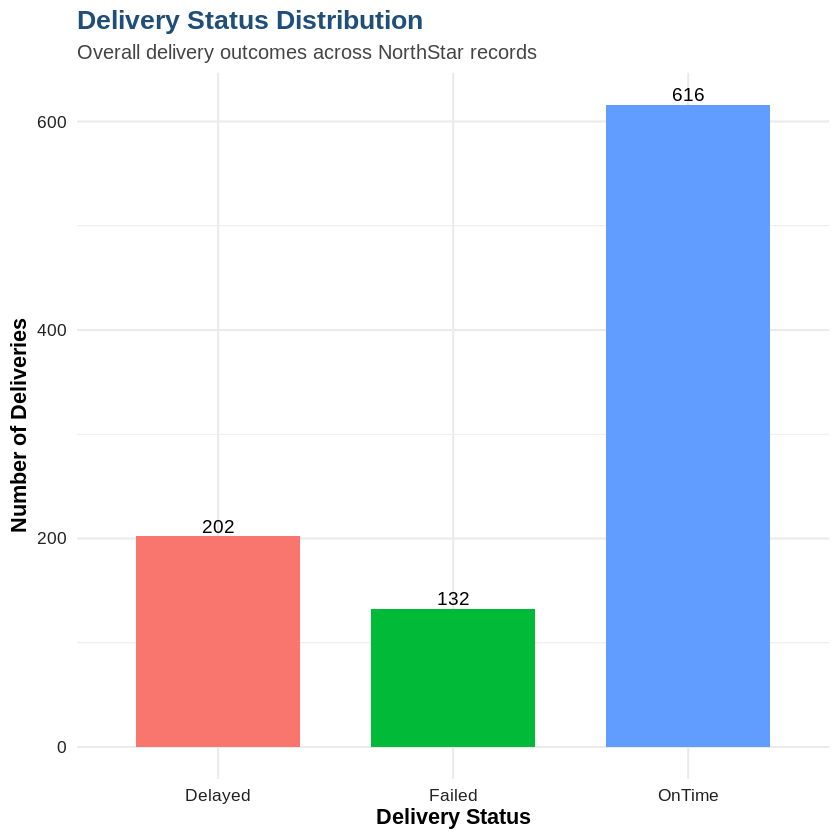

In [11]:
# ============================================================
# Step 7: R Analytics Chart 1 - Delivery Status Distribution
# ============================================================
# Purpose:
# Show how many deliveries fall into each delivery status category.
#
# Business justification:
# This gives a high-level view of NorthStar's overall delivery
# reliability before deeper hub and route analysis.
# ============================================================

ggplot(deliveries, aes(x = delivery_status, fill = delivery_status)) +
  geom_bar(width = 0.7, show.legend = FALSE) +
  geom_text(
    stat = "count",
    aes(label = after_stat(count)),
    vjust = -0.3,
    size = 4
  ) +
  labs(
    title = "Delivery Status Distribution",
    subtitle = "Overall delivery outcomes across NorthStar records",
    x = "Delivery Status",
    y = "Number of Deliveries"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16, color = "#1F4E79"),
    plot.subtitle = element_text(size = 12, color = "#444444"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(color = "#222222")
  )

In [12]:
# ============================================================
# Step 8: Prepare Hub Performance Summary for R Analytics
# ============================================================
# Purpose:
# Create a hub-level summary using dplyr for visual analysis.
# ============================================================

hub_performance_r <- deliveries %>%
  left_join(hubs, by = "hub_id") %>%
  group_by(hub_name, zone) %>%
  summarise(
    Total_Deliveries = n(),
    Failed_Deliveries = sum(delivery_status == "Failed", na.rm = TRUE),
    Delayed_Deliveries = sum(delivery_status == "Delayed", na.rm = TRUE),
    OnTime_Deliveries = sum(delivery_status == "OnTime", na.rm = TRUE),
    Failure_Rate_Percent = round(100 * Failed_Deliveries / Total_Deliveries, 2),
    Delay_Rate_Percent = round(100 * Delayed_Deliveries / Total_Deliveries, 2),
    Avg_Route_Distance_KM = round(mean(route_distance_km, na.rm = TRUE), 2),
    Avg_Fuel_Charge_Cost = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  arrange(desc(Failed_Deliveries + Delayed_Deliveries))

nice_table(
  hub_performance_r,
  title = "R Analytics: Hub Performance Summary"
)

hub_name,zone,Total_Deliveries,Failed_Deliveries,Delayed_Deliveries,OnTime_Deliveries,Failure_Rate_Percent,Delay_Rate_Percent,Avg_Route_Distance_KM,Avg_Fuel_Charge_Cost
Central Core,Central,115,23,25,67,20.00,21.74,14.32,13.69
Midtown Relay,Central,128,26,22,80,20.31,17.19,12.82,11.71
West Gate,West,127,16,28,83,12.60,22.05,13.38,13.17
North Exchange,North,136,17,26,93,12.50,19.12,13.64,12.76
Airport Hub,Airport,104,15,27,62,14.42,25.96,14.41,13.32
Riverside Hub,Riverside,115,14,25,76,12.17,21.74,14.29,12.92
South Link,South,106,10,26,70,9.43,24.53,14.17,12.56
East Dock,East,119,11,23,85,9.24,19.33,14.52,12.74


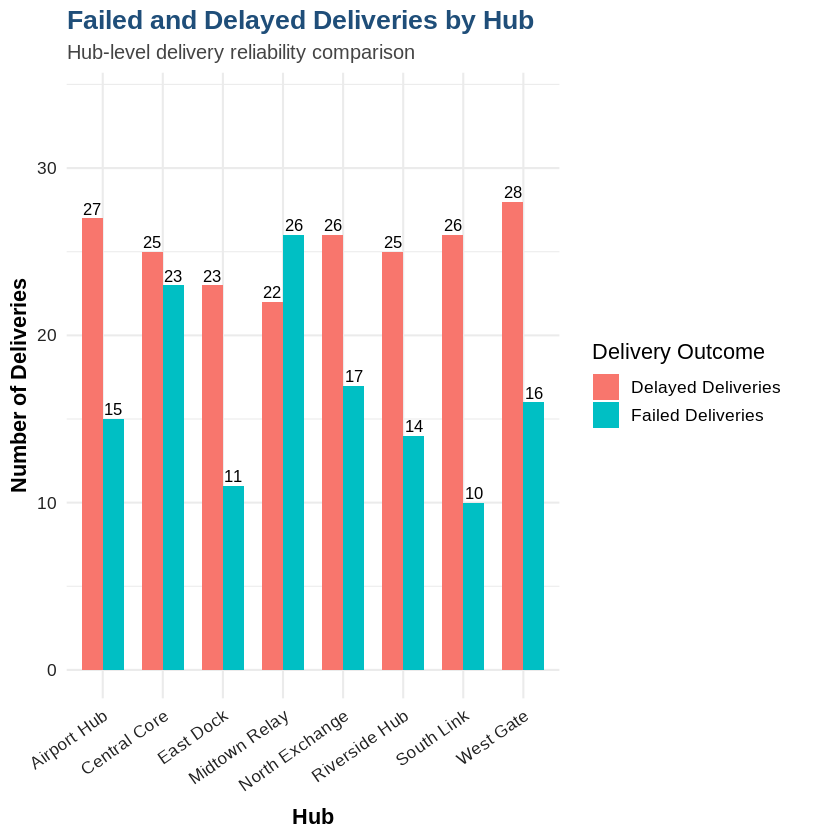

In [13]:
# ============================================================
# Step 9: R Analytics Chart 2 - Failed and Delayed Deliveries by Hub
# ============================================================
# Purpose:
# Compare failed and delayed deliveries across each hub.
#
# Business justification:
# This identifies hubs where operational reliability issues are
# concentrated.
# ============================================================

hub_status_chart <- data.frame(
  Hub = rep(hub_performance_r$hub_name, 2),
  Status = c(
    rep("Failed Deliveries", nrow(hub_performance_r)),
    rep("Delayed Deliveries", nrow(hub_performance_r))
  ),
  Count = c(
    hub_performance_r$Failed_Deliveries,
    hub_performance_r$Delayed_Deliveries
  )
)

ggplot(
  hub_status_chart,
  aes(
    x = Hub,
    y = Count,
    fill = Status
  )
) +
  geom_col(position = "dodge", width = 0.7) +
  geom_text(
    aes(label = Count),
    position = position_dodge(width = 0.7),
    vjust = -0.3,
    size = 3.5
  ) +
  labs(
    title = "Failed and Delayed Deliveries by Hub",
    subtitle = "Hub-level delivery reliability comparison",
    x = "Hub",
    y = "Number of Deliveries",
    fill = "Delivery Outcome"
  ) +
  ylim(0, max(hub_status_chart$Count) + 6) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16, color = "#1F4E79"),
    plot.subtitle = element_text(size = 12, color = "#444444"),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 35, hjust = 1, color = "#222222"),
    axis.text.y = element_text(color = "#222222"),
    legend.position = "right"
  )

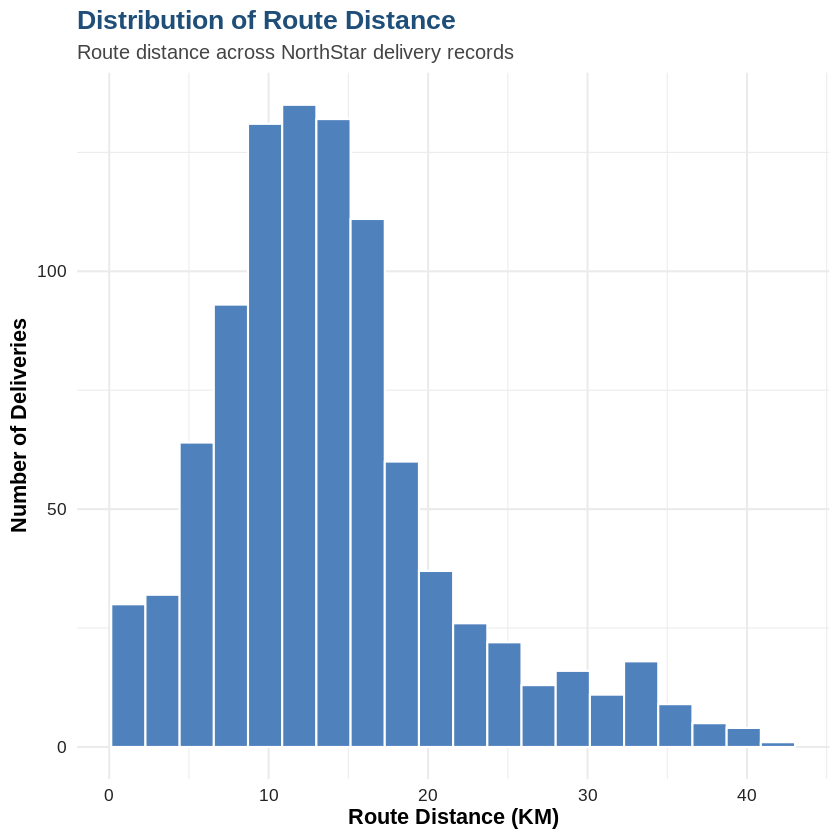

In [14]:
# ============================================================
# Step 10: R Analytics Chart 3 - Route Distance Distribution
# ============================================================
# Purpose:
# Show the distribution of route distances across delivery records.
#
# Business justification:
# Route distance affects fuel/charge cost, driver workload and
# probability of delay.
# ============================================================

ggplot(
  deliveries,
  aes(x = route_distance_km)
) +
  geom_histogram(
    bins = 20,
    fill = "#4F81BD",
    color = "white"
  ) +
  labs(
    title = "Distribution of Route Distance",
    subtitle = "Route distance across NorthStar delivery records",
    x = "Route Distance (KM)",
    y = "Number of Deliveries"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16, color = "#1F4E79"),
    plot.subtitle = element_text(size = 12, color = "#444444"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(color = "#222222")
  )

In [15]:
# ============================================================
# Step 11: Prepare Route Override Summary
# ============================================================
# Purpose:
# Summarise manual route override pressure by delivery status.
# ============================================================

route_override_status <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(
    Total_Deliveries = n(),
    Avg_Manual_Overrides = round(mean(manual_route_override_count, na.rm = TRUE), 2),
    Avg_Route_Distance_KM = round(mean(route_distance_km, na.rm = TRUE), 2),
    Avg_Customer_Rating = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    Avg_Fuel_Charge_Cost = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  arrange(desc(Avg_Manual_Overrides))

nice_table(
  route_override_status,
  title = "R Analytics: Route Override Pressure by Delivery Status"
)

delivery_status,Total_Deliveries,Avg_Manual_Overrides,Avg_Route_Distance_KM,Avg_Customer_Rating,Avg_Fuel_Charge_Cost
Delayed,202,1.07,14.67,3.11,13.14
Failed,132,1.04,13.37,3.05,13.15
OnTime,616,0.92,13.78,4.28,12.68


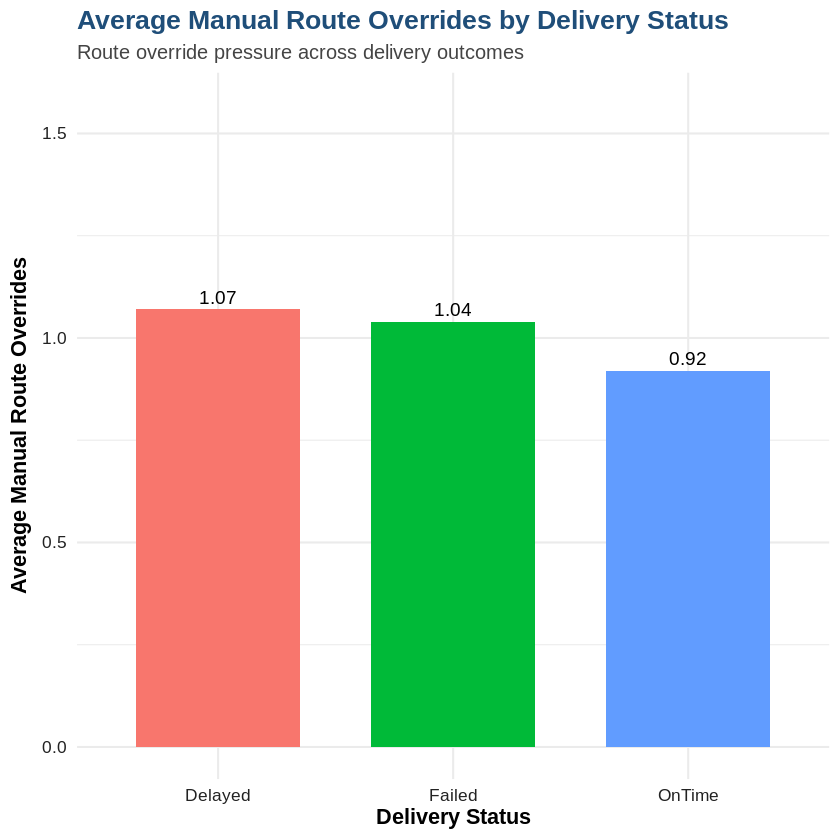

In [16]:
# ============================================================
# Step 12: R Analytics Chart 4 - Route Override Pressure
# ============================================================
# Purpose:
# Visualise average manual route overrides by delivery status.
#
# Business justification:
# This tests whether manual route changes are linked with delayed
# or failed service outcomes.
# ============================================================

ggplot(
  route_override_status,
  aes(
    x = delivery_status,
    y = Avg_Manual_Overrides,
    fill = delivery_status
  )
) +
  geom_col(width = 0.7, show.legend = FALSE) +
  geom_text(
    aes(label = Avg_Manual_Overrides),
    vjust = -0.4,
    size = 4
  ) +
  labs(
    title = "Average Manual Route Overrides by Delivery Status",
    subtitle = "Route override pressure across delivery outcomes",
    x = "Delivery Status",
    y = "Average Manual Route Overrides"
  ) +
  ylim(0, max(route_override_status$Avg_Manual_Overrides) + 0.5) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16, color = "#1F4E79"),
    plot.subtitle = element_text(size = 12, color = "#444444"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(color = "#222222")
  )

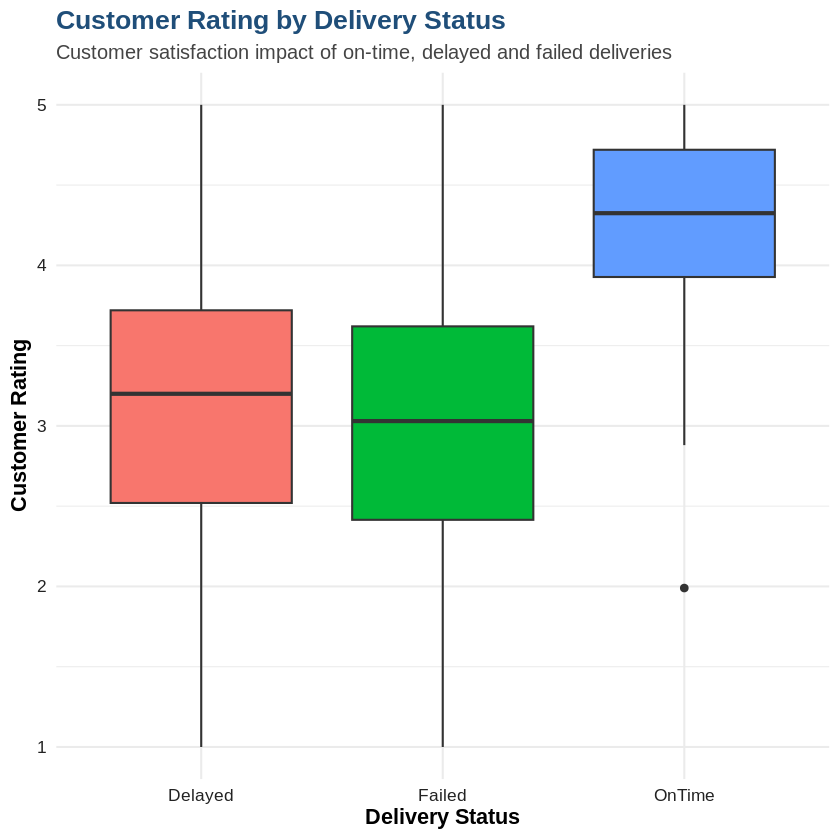

In [17]:
# ============================================================
# Step 13: R Analytics Chart 5 - Customer Rating by Delivery Status
# ============================================================
# Purpose:
# Compare customer rating distributions across delivery outcomes.
#
# Business justification:
# This shows whether poor delivery outcomes are associated with
# lower customer satisfaction.
# ============================================================

rating_clean <- deliveries %>%
  filter(!is.na(customer_rating_post_delivery))

ggplot(
  rating_clean,
  aes(
    x = delivery_status,
    y = customer_rating_post_delivery,
    fill = delivery_status
  )
) +
  geom_boxplot(show.legend = FALSE) +
  labs(
    title = "Customer Rating by Delivery Status",
    subtitle = "Customer satisfaction impact of on-time, delayed and failed deliveries",
    x = "Delivery Status",
    y = "Customer Rating"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 16, color = "#1F4E79"),
    plot.subtitle = element_text(size = 12, color = "#444444"),
    axis.title = element_text(face = "bold"),
    axis.text = element_text(color = "#222222")
  )

In [18]:
# ============================================================
# Step 14: Final R Analytics Summary
# ============================================================
# Purpose:
# Summarise the main analytical findings produced in this R notebook.
# ============================================================

r_analytics_summary <- data.frame(
  Analysis_Area = c(
    "Delivery reliability",
    "Hub performance",
    "Route distance",
    "Manual route overrides",
    "Customer satisfaction"
  ),
  Key_Finding = c(
    "Delivery status distribution provides a high-level view of on-time, delayed and failed service outcomes.",
    "Hub analysis identifies where failed and delayed deliveries are concentrated.",
    "Route distance distribution highlights the operational spread of delivery journeys and possible long-route pressure.",
    "Manual route override analysis checks whether routing changes are associated with poorer delivery outcomes.",
    "Customer rating analysis shows whether delayed or failed deliveries are linked with lower satisfaction."
  ),
  Business_Value = c(
    "Supports service reliability monitoring.",
    "Helps prioritise hubs for operational review.",
    "Supports route planning and cost control.",
    "Helps evaluate routing process effectiveness.",
    "Connects operational performance with customer experience."
  )
)

nice_table(
  r_analytics_summary,
  title = "Final R Analytics Summary"
)

Analysis_Area,Key_Finding,Business_Value
Delivery reliability,"Delivery status distribution provides a high-level view of on-time, delayed and failed service outcomes.",Supports service reliability monitoring.
Hub performance,Hub analysis identifies where failed and delayed deliveries are concentrated.,Helps prioritise hubs for operational review.
Route distance,Route distance distribution highlights the operational spread of delivery journeys and possible long-route pressure.,Supports route planning and cost control.
Manual route overrides,Manual route override analysis checks whether routing changes are associated with poorer delivery outcomes.,Helps evaluate routing process effectiveness.
Customer satisfaction,Customer rating analysis shows whether delayed or failed deliveries are linked with lower satisfaction.,Connects operational performance with customer experience.
